<h1>EN 3160 - Assignment 1</h1>
<h2>Intensity Transformations and Neighborhood Filtering</h2>
<h3>Index No. - 230013A</h3>

# Question 1

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def intensity_transform(im, xp, fp):
    """Builds a lookup table according to break points and applies the lut to the image"""
    lut = np.interp(np.arange(256), xp, fp).astype(np.uint8)
    transformed_image = transformed_image = cv.LUT(im, lut)
    return transformed_image

im = cv.imread("images/q1.jpeg", cv.IMREAD_GRAYSCALE)

xp = [0, 50, 50, 150, 150, 255]
fp = [0, 50, 100, 255, 150, 255]

transformed_image = intensity_transform(im, xp, fp)


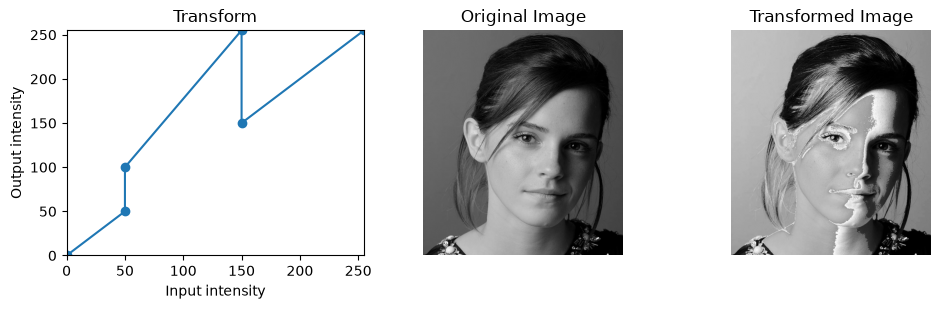

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))

axes[0].plot(xp, fp, 'o-')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel("Input intensity")
axes[0].set_ylabel("Output intensity")
axes[0].set_title("Transform")

axes[1].imshow(im, cmap='gray', vmin=0, vmax=255)
axes[1].axis('off')
axes[1].set_title("Original Image")

axes[2].imshow(transformed_image, cmap='gray', vmin=0, vmax=255)
axes[2].axis('off')
axes[2].set_title("Transformed Image")

plt.tight_layout()
plt.show()

At first, the transformation given in Fig. 1a was used, which had abrupt jumps at intensities of 50 and 150, and therefore resulted in discontinuous inversions in mid-tone values.

In [13]:
# For a visually pleasing output
xp = [0, 50, 100, 150, 200, 255]
fp = [0, 30, 100, 150, 255, 255]

transformed_image = intensity_transform(im, xp, fp)

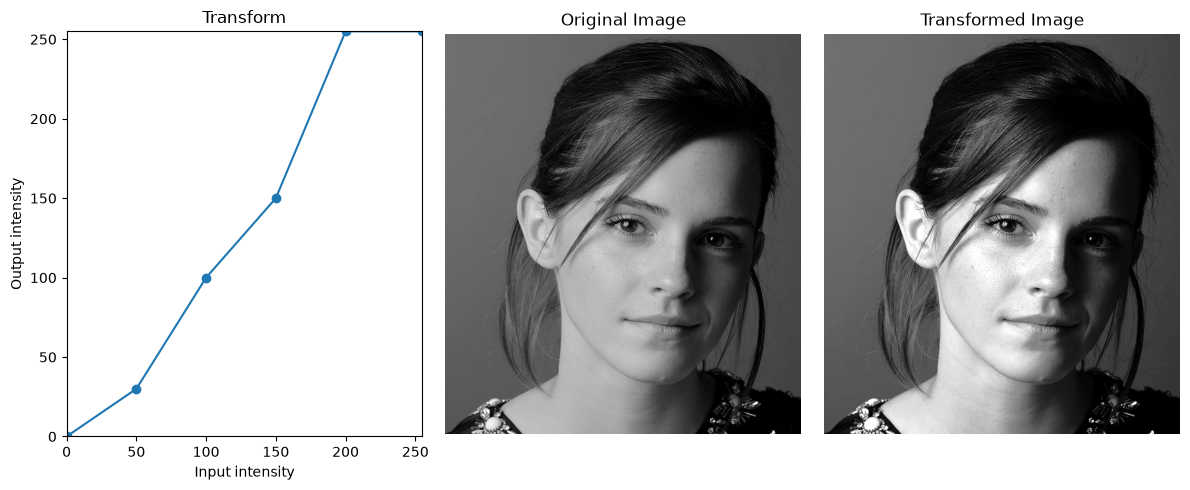

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].plot(xp, fp, 'o-')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel("Input intensity")
axes[0].set_ylabel("Output intensity")
axes[0].set_title("Transform")

axes[1].imshow(im, cmap='gray', vmin=0, vmax=255)
axes[1].axis('off')
axes[1].set_title("Original Image")

axes[2].imshow(transformed_image, cmap='gray', vmin=0, vmax=255)
axes[2].axis('off')
axes[2].set_title("Transformed Image")

plt.tight_layout()
plt.show()

After consulting the histogram of the image, the transform was altered to compress both higher and lower intensity values, which resulted in a visually pleasing contrast enhancement on the image.

# Question 2

In [51]:
im = cv.imread("images/q2.jpeg")

#Transformation for white matter
xp_wm = [0, 100, 140, 150, 160, 170, 180, 190, 220, 255]
fp_wm = [0,   0,   0,   0,   0,  30,  62, 150, 255, 255]
#Transformation for gray matter
xp_gm = [0, 100, 140, 150, 160, 170, 180, 190, 200, 255]
fp_gm = [0,   0,   0,   0,  66, 121, 182, 255, 255, 255]

transformed_image_wm = intensity_transform(im, xp_wm, fp_wm)
transformed_image_gm = intensity_transform(im, xp_gm, fp_gm)

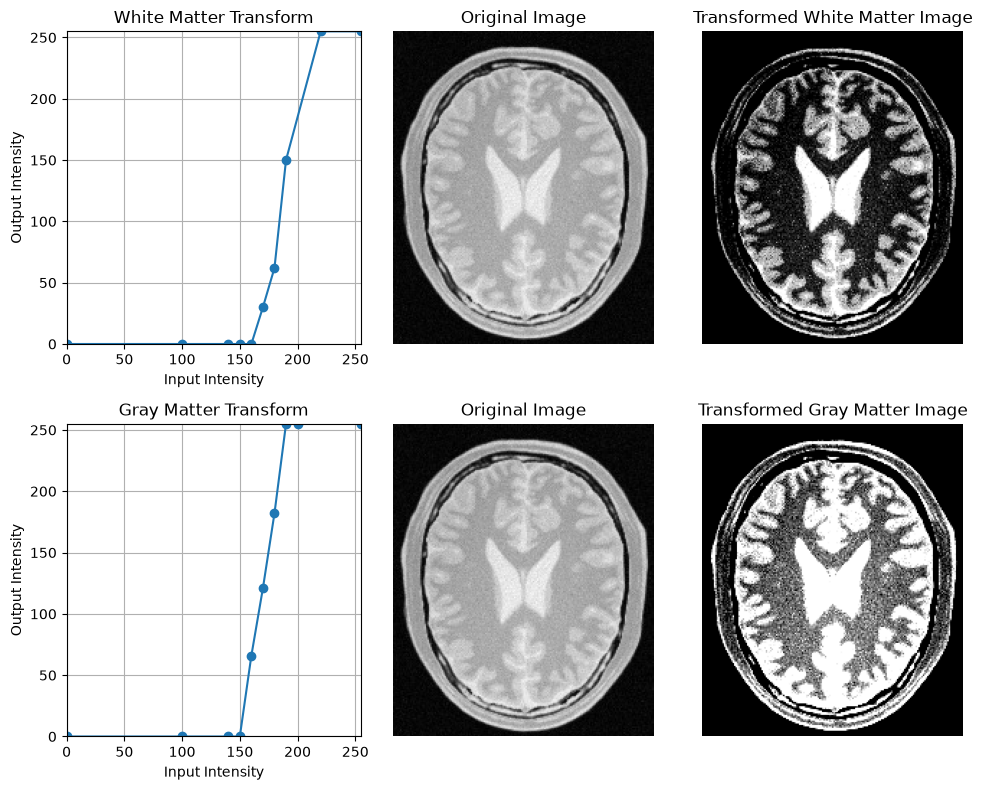

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(10, 8))

axes[0][0].plot(xp_wm, fp_wm, 'o-')
axes[0][0].set_xlim(0, 255)
axes[0][0].set_ylim(0, 255)
axes[0][0].grid(True)
axes[0][0].set_xlabel("Input Intensity")
axes[0][0].set_ylabel("Output Intensity")
axes[0][0].set_title("White Matter Transform")

axes[0][1].imshow(im, cmap='gray', vmin=0, vmax=255)
axes[0][1].axis('off')
axes[0][1].set_title("Original Image")

axes[0][2].imshow(transformed_image_wm, cmap='gray', vmin=0, vmax=255)
axes[0][2].axis('off')
axes[0][2].set_title("Transformed White Matter Image")

axes[1][0].plot(xp_gm, fp_gm, 'o-')
axes[1][0].set_xlim(0, 255)
axes[1][0].set_ylim(0, 255)
axes[1][0].grid(True)
axes[1][0].set_xlabel("Input Intensity")
axes[1][0].set_ylabel("Output Intensity")
axes[1][0].set_title("Gray Matter Transform")

axes[1][1].imshow(im, cmap='gray', vmin=0, vmax=255)
axes[1][1].axis('off')
axes[1][1].set_title("Original Image")

axes[1][2].imshow(transformed_image_gm, cmap='gray', vmin=0, vmax=255)
axes[1][2].axis('off')
axes[1][2].set_title("Transformed Gray Matter Image")

plt.tight_layout()
plt.show()

The same piecewise-linear transformation approach from Q1 was applied here, and two separate transforms were used for gray matter (boundary) and white matter (middle) separately. At first, different pixel values were samples using a color picker to approximate the boundaries of gray and white matter. Later, a slider based approach was utilized to find the transformations best suited for each image. For the white matter image, the middle area was to be accentuated, so it has a steeper slope at 160-220, whereas for the gray matter image, the boundary areas had to be emphasized, so it was given a steeper slope at 150-190 (compressing background and increasing bright areas for better contrast).

# Question 3

In [10]:
def gamma_correct(im, gamma):
    lut = np.array([((i/255.0)**gamma)*255 for i in np.arange(0, 256)]).astype("uint8")
    return cv.LUT(im, lut)

im = cv.imread("images/q3.jpeg")
im_lab = cv.cvtColor(im, cv.COLOR_BGR2LAB) # L-illumination | a,b-color space
l_channel, a_channel, b_channel = cv.split(im_lab) # Image is split into L, a and b channels.

gamma = 0.65 # Gamma value
gamma_corrected_l = gamma_correct(l_channel, gamma)
reconstructed_im_lab = cv.merge([gamma_corrected_l, a_channel, b_channel])

# Histograms
im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)
hist = cv.calcHist([l_channel], [0], None, [256], [0,256])
reconstructed_im_rgb = cv.cvtColor(reconstructed_im_lab, cv.COLOR_LAB2RGB)
gamma_hist = cv.calcHist([reconstructed_im_rgb], [0], None, [256], [0,256])

Text(0.5, 1.0, 'Corrected Image')

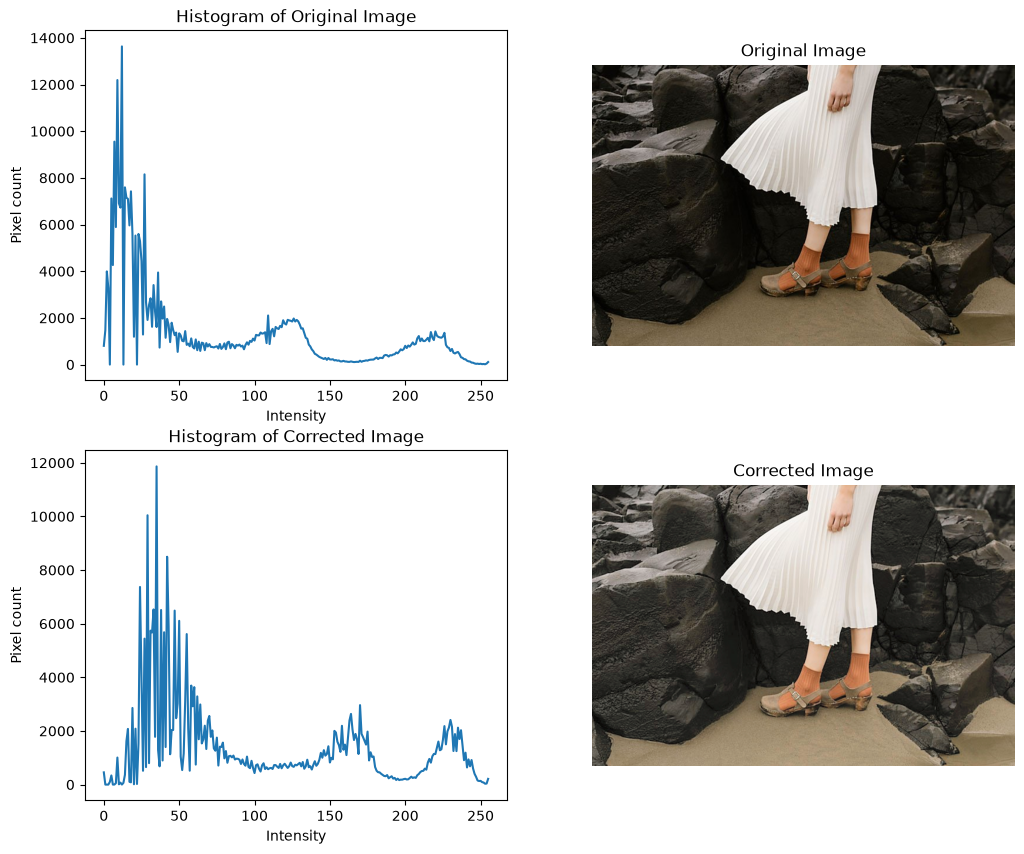

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0][0].plot(hist)
axes[0][0].set_xlabel("Intensity")
axes[0][0].set_ylabel("Pixel count")
axes[0][0].set_title("Histogram of Original Image")

axes[0][1].imshow(im_rgb)
axes[0][1].axis('off')
axes[0][1].set_title("Original Image")

axes[1][0].plot(gamma_hist)
axes[1][0].set_xlabel("Intensity")
axes[1][0].set_ylabel("Pixel count")
axes[1][0].set_title("Histogram of Corrected Image")

axes[1][1].imshow(reconstructed_im_rgb)
axes[1][1].axis('off')
axes[1][1].set_title("Corrected Image")

The image was separated into L,a,b channels and the L plane was gamma corrected with a $\gamma$ value of 0.65 (Because the original image had too dark shadows, $\gamma$ should be < 1). The gamma corrected image has more visible shadows (dark areas), and this is evident from the histogram, which has moved right, giving higher pixel counts to higher intensities.

# Question 4

In [58]:
def vibrance_transform(i, a, sigma):
    f_inter = i + a*128*np.exp(-(i-128)**2/(2*sigma**2))
    f = min(f_inter, 255)
    return f

im = cv.imread("images/q4.jpeg")
im_hsv = cv.cvtColor(im, cv.COLOR_BGR2HSV)
hue, saturation, value = cv.split(im_hsv)

a = 0.8 # a value
sigma = 70

lut = np.array([vibrance_transform(i, a, sigma) for i in np.arange(0, 256)]).astype("uint8")
im_sat_tform = cv.LUT(saturation, lut)

vibr_hsv = cv.merge([hue, im_sat_tform, value]) # Three planes are recombined.

Text(0.5, 1.0, 'Vibrance Transformed Image')

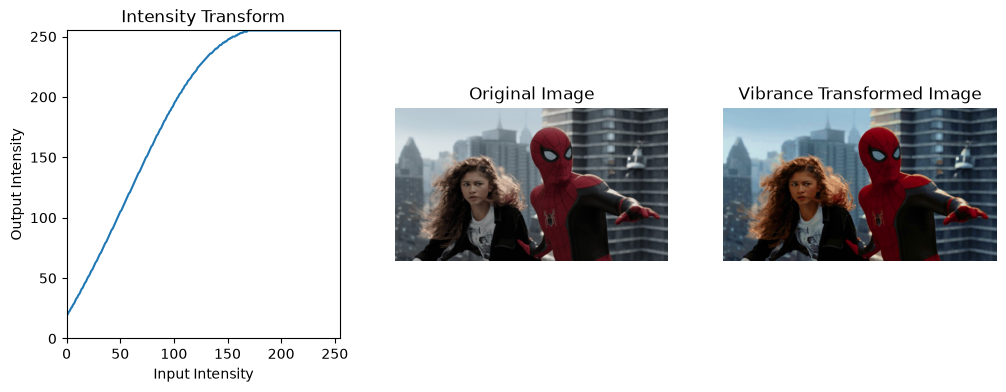

In [59]:
im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)
vibr_rgb = cv.cvtColor(vibr_hsv, cv.COLOR_HSV2RGB)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(np.arange(256), lut)
axes[0].set_xlim(0,255)
axes[0].set_ylim(0,255)
axes[0].set_xlabel("Input Intensity")
axes[0].set_ylabel("Output Intensity")
axes[0].set_title("Intensity Transform")

axes[1].imshow(im_rgb)
axes[1].axis('off')
axes[1].set_title("Original Image")

axes[2].imshow(vibr_rgb)
axes[2].axis('off')
axes[2].set_title("Vibrance Transformed Image")

Intensity transform,

$f(x) = min(i + a.128.e^{\frac{-(i-128)^2}{(2\sigma^2)}}, 255)$

was applied to the saturation plane of the image. At $\sigma$ = 70, the value of $a$ was chosen to be 0.8 to give a more visually pleasing result. As seen in the intensity transformation plot, the transform behaves like a boosted near-linear curve that saturates to 255 at higher input saturations. The result is, the overall vibrance of the image is increased, while keeping skin tones and other less saturated areas at a reasonable level.

# Question 5

In [60]:
im = cv.imread("images/shells.tif", cv.IMREAD_GRAYSCALE)
old_hist = cv.calcHist([im], [0], None, [256], [0,256])

def histogram_equalizer(im, hist):
    cdf = np.cumsum(old_hist)
    cdf_min = cdf[cdf > 0].min()
    lut = np.round((cdf-cdf_min) / (im.size-cdf_min) * 255).astype(np.uint8)
    lut = np.clip(lut, 0, 255)
    equalized_image = cv.LUT(im, lut)
    return equalized_image

equalized_image = histogram_equalizer(im, old_hist)
new_hist = cv.calcHist([equalized_image], [0], None, [256], [0,256])

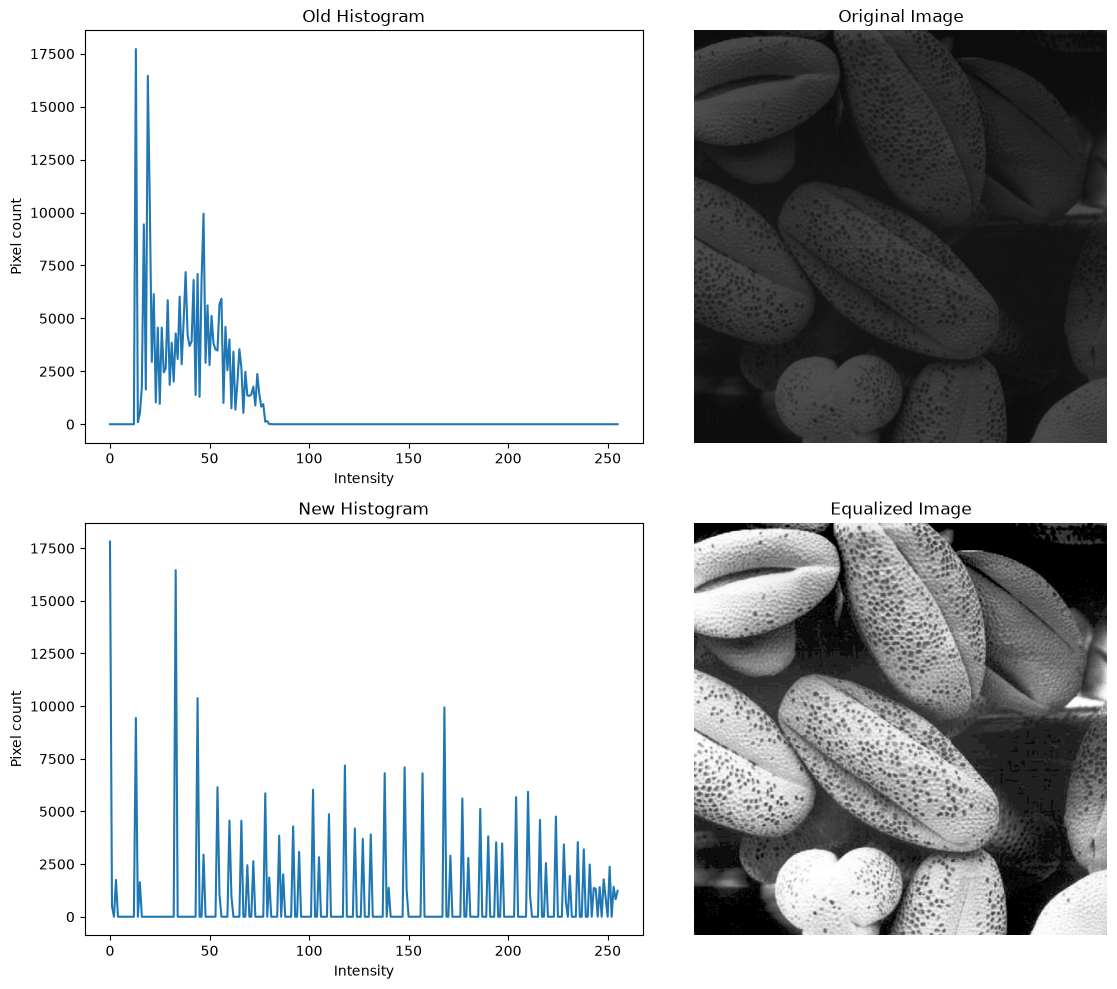

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0][0].plot(old_hist)
axes[0][0].set_xlabel("Intensity")
axes[0][0].set_ylabel("Pixel count")
axes[0][0].set_title("Old Histogram")

axes[0][1].imshow(im, cmap='gray', vmin=0, vmax=255)
axes[0][1].axis('off')
axes[0][1].set_title("Original Image")

axes[1][0].plot(new_hist)
axes[1][0].set_xlabel("Intensity")
axes[1][0].set_ylabel("Pixel count")
axes[1][0].set_title("New Histogram")

axes[1][1].imshow(equalized_image, cmap='gray', vmin=0, vmax=255)
axes[1][1].axis('off')
axes[1][1].set_title("Equalized Image")

plt.tight_layout()
plt.show()

The function for histogram equalization was written according to standard practices, with
min-max normalizing. As in above implementations, a lookup table was used to map values.

Equalization formula = $\frac{CDF - CDF_{min}}{MN - CDF_{min}}*(L-1)$

The result was an image with brighter highlights, and darker shadows, with clear contrast instead of the same grayish look of the original.

# Question 6

In [62]:
im = cv.imread("images/q6.jpeg")
im_hsv = cv.cvtColor(im, cv.COLOR_BGR2HSV)
hue, saturation, value = cv.split(im_hsv)

Text(0.5, 1.0, 'Value')

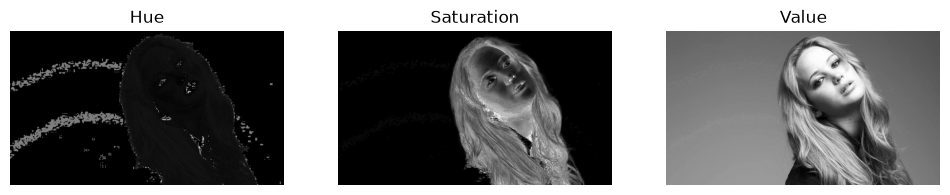

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].imshow(hue, cmap='gray', vmin=0, vmax=255)
axes[0].axis('off')
axes[0].set_title("Hue")

axes[1].imshow(saturation, cmap='gray', vmin=0, vmax=255)
axes[1].axis('off')
axes[1].set_title("Saturation")

axes[2].imshow(value, cmap='gray', vmin=0, vmax=255)
axes[2].axis('off')
axes[2].set_title("Value")

From the above planes, saturation was chosen to extract the foreground, because it has the most separation between the background and the foreground.

In [68]:
thresh_val = 13 # Threshold value was taken as 13 for better separation.
_, mask = cv.threshold(saturation, thresh_val, 255, cv.THRESH_BINARY) # Calculating mask

foreground = cv.bitwise_and(im, im, mask=mask)  #extract foreground
fore_hist = cv.calcHist([im], [0], mask, [256], [0,256]).flatten()  # Histogram
cdf = np.cumsum(fore_hist)      # Cumulative Sum of Histogram

In [80]:
MN = np.sum(fore_hist)
L = 256
lut = np.round((L-1) / MN * cdf).astype(np.uint8) # Normalization was not used since it was not available in slides.
equalized_foreground = cv.LUT(foreground, lut)
new_fore_hist = cv.calcHist([equalized_foreground], [0], mask, [256], [0,256]).flatten()
background = cv.bitwise_and(im, im, mask=cv.bitwise_not(mask))
final_result = cv.add(equalized_foreground, background)

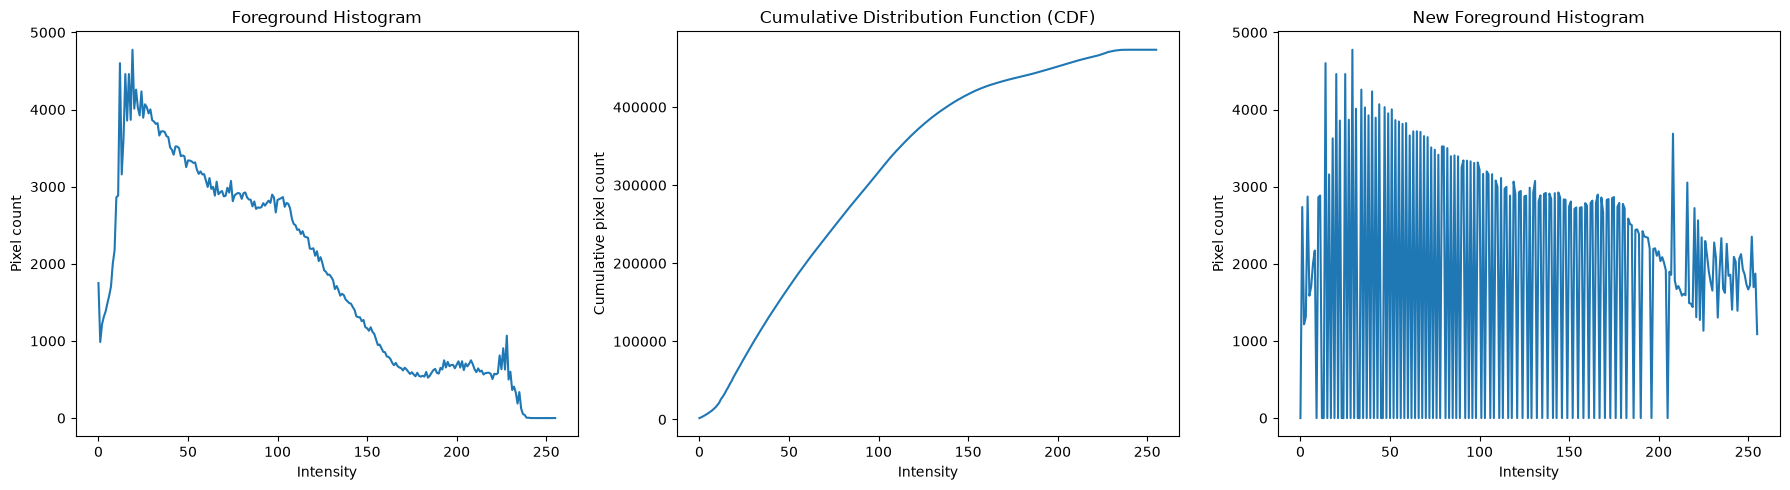

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fore_hist)
axes[0].set_xlabel("Intensity")
axes[0].set_ylabel("Pixel count")
axes[0].set_title("Foreground Histogram")

axes[1].plot(cdf)
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Cumulative pixel count")
axes[1].set_title("Cumulative Distribution Function (CDF)")

axes[2].plot(new_fore_hist)
axes[2].set_xlabel("Intensity")
axes[2].set_ylabel("Pixel count")
axes[2].set_title("New Foreground Histogram")

plt.tight_layout()
plt.show()

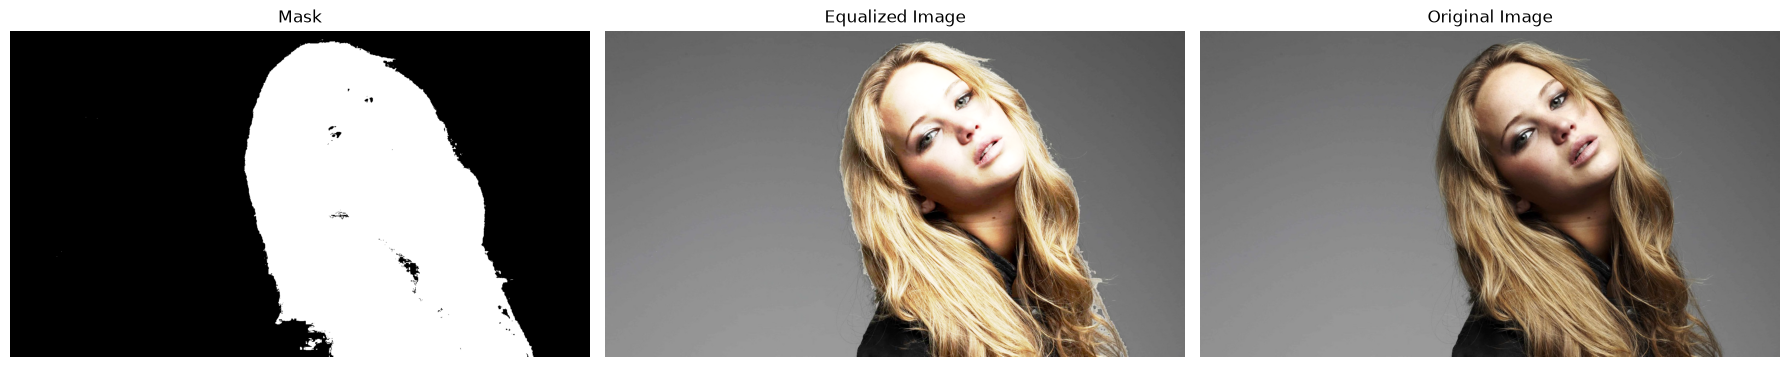

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(cv.cvtColor(mask, cv.COLOR_BGR2RGB))
axes[0].axis('off')
axes[0].set_title("Mask")

axes[1].imshow(cv.cvtColor(final_result, cv.COLOR_BGR2RGB))
axes[1].axis('off')
axes[1].set_title("Equalized Image")

axes[2].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
axes[2].axis('off')
axes[2].set_title("Original Image")

plt.tight_layout()
plt.show()

Thresholding the saturation plane at 13 gave a clean binary mask isolating only the subject's silhouette. The foreground was extracted using *cv.bitwise_and* with the mask and the histogram was calculated with it too, to avoid background pixels. Equalization was applied using the formula in the slides, (without normalization)

Equalization = $\frac{(L-1)}{MN}CDF$

The resulting image was significantly brighter, and was visually less cinematic than the original (However, even with normalizing, the brightness after equalization would still take place). This is because a histogram equalization optimizes only the statistical spread across the intensity range, and not artistic choice.

# Question 7

First, *cv.filter2D* was used to filter the image, with standard Sobel operators.

In [6]:
im = cv.imread("images/q7.jpeg", cv.IMREAD_GRAYSCALE)

Gx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32)
Gy = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32)

grad_x = cv.filter2D(im, cv.CV_64F, Gx)
grad_y = cv.filter2D(im, cv.CV_64F, Gy)

magnitude = np.sqrt(grad_x**2 + grad_y**2)
magnitude = np.clip(magnitude, 0, 255).astype(np.uint8)

Secondly, a function was written to go pixel by pixel, and manually apply the Sobel filter.

In [7]:
def my_sobel(im, kernel):
    kh, kw = kernel.shape
    pad_h, pad_w = kh//2, kw//2
    padded = np.pad(im, ((pad_h, pad_h),(pad_w, pad_w)), mode='constant')
    out = np.zeros_like(im, dtype=np.float64)
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            out[i,j] = np.sum(region * kernel)
    return out

my_grad_x = my_sobel(im, Gx)
my_grad_y = my_sobel(im, Gy)

my_magnitude = np.sqrt(my_grad_x**2 + my_grad_y**2)
my_magnitude = np.clip(my_magnitude, 0, 255).astype(np.uint8)

Lastly, the 3x3 matrix was represented as the multiplication of two 3x1 and 1x3 matrices, and the Sobel filter was applied using these lower dimension matrices.

In [8]:
gx_matrix_1 = np.array([[1],[2],[1]], dtype=np.float32)
gx_matrix_2 = np.array([1,0,-1], dtype=np.float32)

gy_matrix_1 = np.array([[1],[0],[-1]], dtype=np.float32)
gy_matrix_2 = np.array([1,2,1], dtype=np.float32)

grad_x_sep = cv.filter2D(cv.filter2D(im, cv.CV_64F, gx_matrix_1), cv.CV_64F, gx_matrix_2)
grad_y_sep = cv.filter2D(cv.filter2D(im, cv.CV_64F, gy_matrix_1), cv.CV_64F, gy_matrix_2)

sep_magnitude = np.sqrt(grad_x_sep**2 + grad_y_sep**2)
sep_magnitude = np.clip(sep_magnitude, 0, 255).astype(np.uint8)

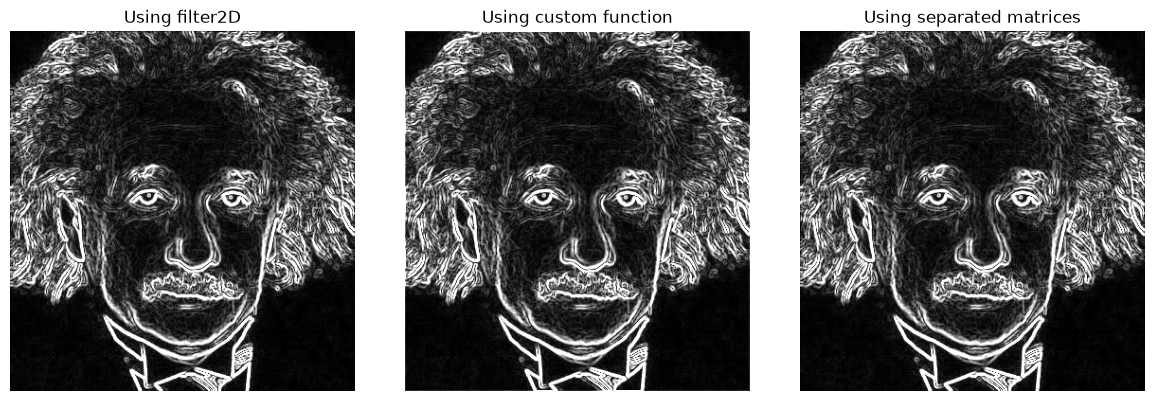

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(magnitude, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Using filter2D")
axes[0].axis('off')

axes[1].imshow(my_magnitude, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Using custom function")
axes[1].axis('off')

axes[2].imshow(sep_magnitude, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Using separated matrices")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [9]:
def compare(a, b, name):
    diff = np.abs(a.astype(int) - b.astype(int))
    ssd = np.sum((a.astype(np.float64) - b.astype(np.float64))**2) / a.size
    print(f"{name}: max diff = {diff.max()}, mean diff = {diff.mean():.3f}, SSD = {ssd:.3f}")
    return diff

diff_sep = compare(magnitude, sep_magnitude, "filter2D vs separable")
diff_man = compare(magnitude, my_magnitude, "filter2D vs manual")

crop = 5
diff_man_cropped = diff_man[crop:-crop, crop:-crop]
print(f"filter2D vs manual (cropped): max = {diff_man_cropped.max()}, mean = {diff_man_cropped.mean():.3f}")

filter2D vs separable: max diff = 0, mean diff = 0.000, SSD = 0.000
filter2D vs manual: max diff = 255, mean diff = 0.846, SSD = 123.905
filter2D vs manual (cropped): max = 0, mean = 0.000


Comparing the three methods, filter2D and separable version were identical (because filter2D function was used with the 1D dimensions themselves). While there were differences between filter2D and the manual convolution method, cropping the image border caused this difference to disappear, since the error rose from the different edge padding methods used, making all three methods result in identical outputs.

# Question 8

In [19]:
def nearest_neighbor(img, s):
    height, width = img.shape[:2]
    s_height, s_width = int(s * height), int(s * width)

    if img.ndim == 3:
        channels = img.shape[2]
        new_img = np.zeros((s_height, s_width, channels), dtype=np.uint8)
    else:
        new_img = np.zeros((s_height, s_width), dtype=np.uint8)

    for r in range(s_height):
        for c in range(s_width):
            r_in = (r + 0.5) / s - 0.5
            c_in = (c + 0.5) / s - 0.5
            r_in = int(round(min(max(r_in, 0), height - 1)))
            c_in = int(round(min(max(c_in, 0), width - 1)))
            new_img[r, c] = img[r_in, c_in]

    return new_img

In [20]:
def bilin_interpolate(img, s):
    height, width = img.shape[:2]
    s_height, s_width = int(s * height), int(s * width)

    if img.ndim == 3:
        channels = img.shape[2]
        new_img = np.zeros((s_height, s_width, channels), dtype=np.float64)
    else:
        new_img = np.zeros((s_height, s_width), dtype=np.float64)

    for r in range(s_height):
        for c in range(s_width):
            r_in = (r + 0.5) / s - 0.5
            c_in = (c + 0.5) / s - 0.5
            r_in = min(max(r_in, 0), height - 1)
            c_in = min(max(c_in, 0), width - 1)
            r0, c0 = int(r_in), int(c_in)
            r1, c1 = min(r0 + 1, height - 1), min(c0 + 1, width - 1)
            dr = r_in - r0
            dc = c_in - c0
            top = (1 - dc) * img[r0, c0] + dc * img[r0, c1]
            bottom = (1 - dc) * img[r1, c0] + dc * img[r1, c1]
            new_img[r, c] = (1 - dr) * top + dr * bottom

    new_img = np.clip(new_img, 0, 255).astype(np.uint8)
    return new_img

In [21]:
im1 = cv.imread("images/im01small.png")
im2 = cv.imread("images/im02small.png")

im1_rgb = cv.cvtColor(im1, cv.COLOR_BGR2RGB) # Image 1
nnim1 = nearest_neighbor(im1_rgb, 4)
biim1 = bilin_interpolate(im1_rgb, 4)

im2_rgb = cv.cvtColor(im2, cv.COLOR_BGR2RGB) # Image 2
nnim2 = nearest_neighbor(im2_rgb, 4)
biim2 = bilin_interpolate(im2_rgb, 4)

In [23]:
im1_scaled = cv.imread("images/im01.png")
im1_scaled_rgb = cv.cvtColor(im1_scaled, cv.COLOR_BGR2RGB)
im2_scaled = cv.imread("images/im02.png")
im2_scaled_rgb = cv.cvtColor(im2_scaled, cv.COLOR_BGR2RGB)

def ssd(img1, img2):
    diff = img1.astype(np.float64) - img2.astype(np.float64)
    return np.mean(diff ** 2)

ssd_nn1 = ssd(nnim1, im1_scaled_rgb)
ssd_bi1 = ssd(biim1, im1_scaled_rgb)

ssd_nn2 = ssd(nnim2, im2_scaled_rgb)
ssd_bi2 = ssd(biim2, im2_scaled_rgb)

print(f"Nearest Neighbor SSD (Image 1): {ssd_nn1}")
print(f"Bilinear Interpolation SSD (Image 1): {ssd_bi1}")
print(f"Nearest Neighbor SSD (Image 2): {ssd_nn2}")
print(f"Bilinear Interpolation SSD (Image 2): {ssd_bi2}")

Nearest Neighbor SSD (Image 1): 136.26904899691357
Bilinear Interpolation SSD (Image 1): 115.12634194958848
Nearest Neighbor SSD (Image 2): 26.446087384259258
Bilinear Interpolation SSD (Image 2): 18.39651909722222


In [26]:
img_nearest = cv.resize(im1_rgb, (1920, 1080), interpolation=cv.INTER_NEAREST)
img_linear = cv.resize(im1_rgb, (1920, 1080), interpolation=cv.INTER_LINEAR)

ssd_nn = ssd(img_nearest, im1_scaled_rgb)
ssd_bi = ssd(img_linear, im1_scaled_rgb)

print(f"Nearest Neighbor SSD (OpenCV) (Image 1): {ssd_nn}")
print(f"Bilinear Interpolation SSD (OpenCV) (Image 1): {ssd_bi}")

img_nearest = cv.resize(im2_rgb, (1920, 1200), interpolation=cv.INTER_NEAREST)
img_linear = cv.resize(im2_rgb, (1920, 1200), interpolation=cv.INTER_LINEAR)

ssd_nn = ssd(img_nearest, im2_scaled_rgb)
ssd_bi = ssd(img_linear, im2_scaled_rgb)

print(f"Nearest Neighbor SSD (OpenCV) (Image 2): {ssd_nn}")
print(f"Bilinear Interpolation SSD (OpenCV) (Image 2): {ssd_bi}")

Nearest Neighbor SSD (OpenCV) (Image 1): 136.26904899691357
Bilinear Interpolation SSD (OpenCV) (Image 1): 115.0919012024177
Nearest Neighbor SSD (OpenCV) (Image 2): 26.446087384259258
Bilinear Interpolation SSD (OpenCV) (Image 2): 18.34591767939815


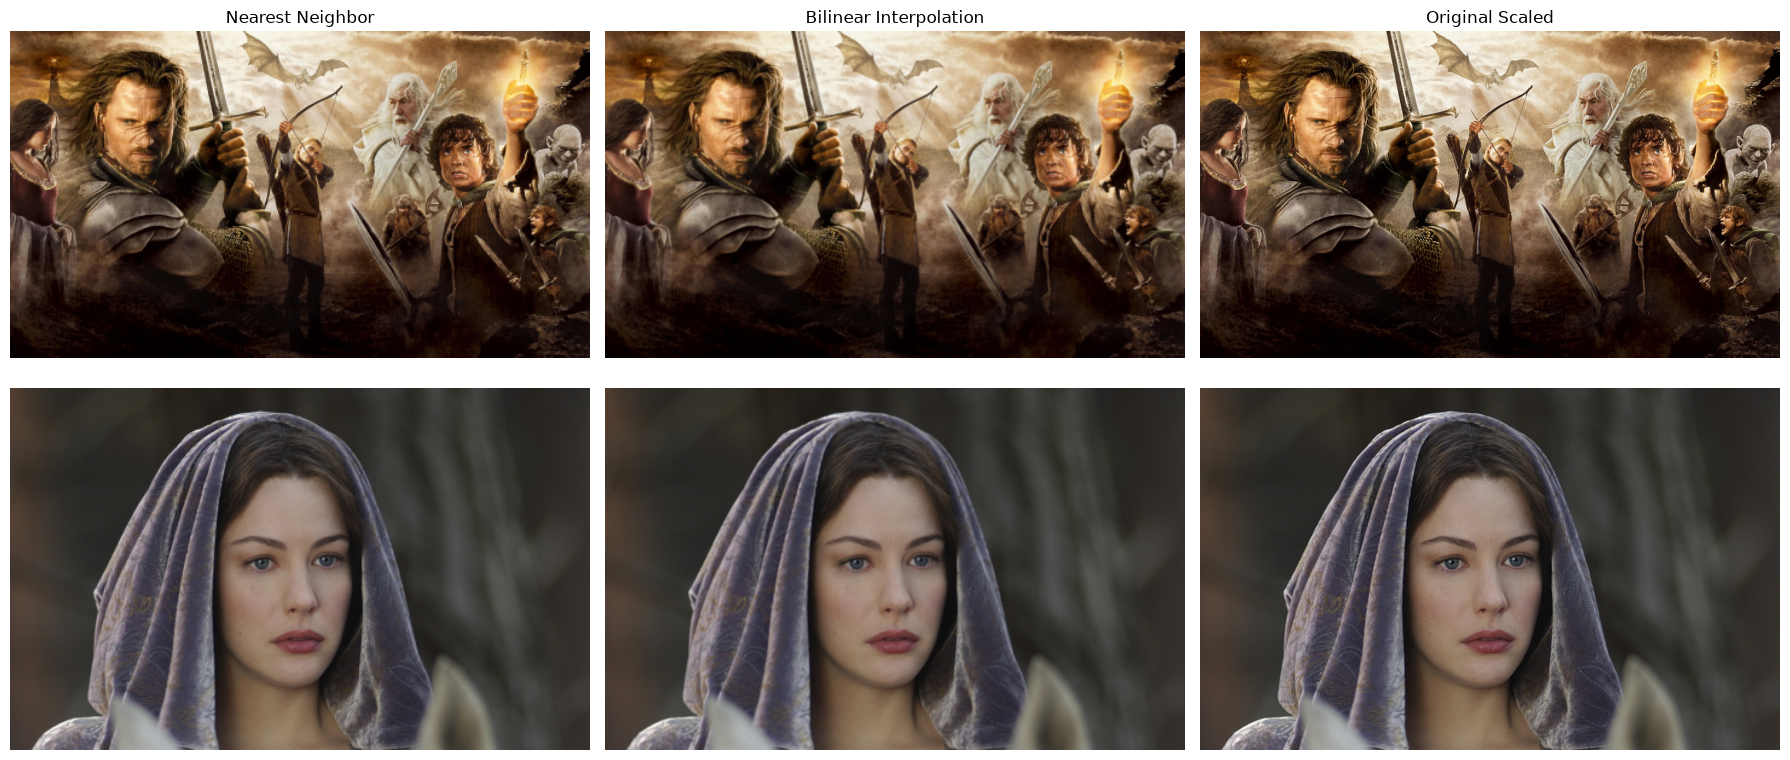

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

axes[0][0].imshow(nnim1)
axes[0][0].set_title("Nearest Neighbor")
axes[0][0].axis('off')

axes[0][1].imshow(biim1)
axes[0][1].set_title("Bilinear Interpolation")
axes[0][1].axis('off')

axes[0][2].imshow(im1_scaled_rgb)
axes[0][2].set_title("Original Scaled")
axes[0][2].axis('off')

axes[1][0].imshow(nnim2)
axes[1][0].axis('off')

axes[1][1].imshow(biim2)
axes[1][1].axis('off')

axes[1][2].imshow(im2_scaled_rgb)
axes[1][2].axis('off')

plt.tight_layout()
plt.show()

Zooming an image can be done through backward coordinate mapping. In this question, two methods were implemented, nearest neighbor (rounding to the nearest integer pixel in the source image), and bilinear interpolation (blending values from four surrounding pixels).

First, the two methods were implemented from scratch, and their outputs were tested against the true scaled image. Calculating the SSD (Sum of Squared Differences) gave the following results.

Nearest Neighbor SSD (Image 1): 136.26904899691357 \
Bilinear Interpolation SSD (Image 1): 115.12634194958848 \
Nearest Neighbor SSD (Image 2): 26.446087384259258 \
Bilinear Interpolation SSD (Image 2): 18.39651909722222

Compared with OpenCV's own nearest neighbor and bilinear interpolation methods.

Nearest Neighbor SSD (OpenCV) (Image 1): 136.26904899691357 \
Bilinear Interpolation SSD (OpenCV) (Image 1): 115.0919012024177 \
Nearest Neighbor SSD (OpenCV) (Image 2): 26.446087384259258 \
Bilinear Interpolation SSD (OpenCV) (Image 2): 18.34591767939815

In all scenarios, bilinear interpolation results in a better approximation than nearest neighbor. This is to be expected, since BI uses four neighboring values for its interpolation, resulting in a more accurate value approximation than just one value in nearest neighbor.

# Question 9

In [27]:
im = cv.imread("images/q9.jpeg")
mask = np.zeros(im.shape[:2], dtype=np.uint8)
bgd_model = np.zeros((1,65), np.float64)
fgd_model = np.zeros((1,65), np.float64)
rect = (50, 150, 510, 450)

cv.grabCut(im, mask, rect, bgd_model, fgd_model, 5, cv.GC_INIT_WITH_RECT)

final_mask = np.where((mask==2)|(mask==0), 0, 1).astype('uint8')
foreground = im * final_mask[:,:,np.newaxis]
background = im * (1 - final_mask[:,:,np.newaxis])

blurred = cv.GaussianBlur(background, (35,35), 0)
result = im * final_mask[:,:,np.newaxis] + blurred * (1-final_mask[:,:,np.newaxis])

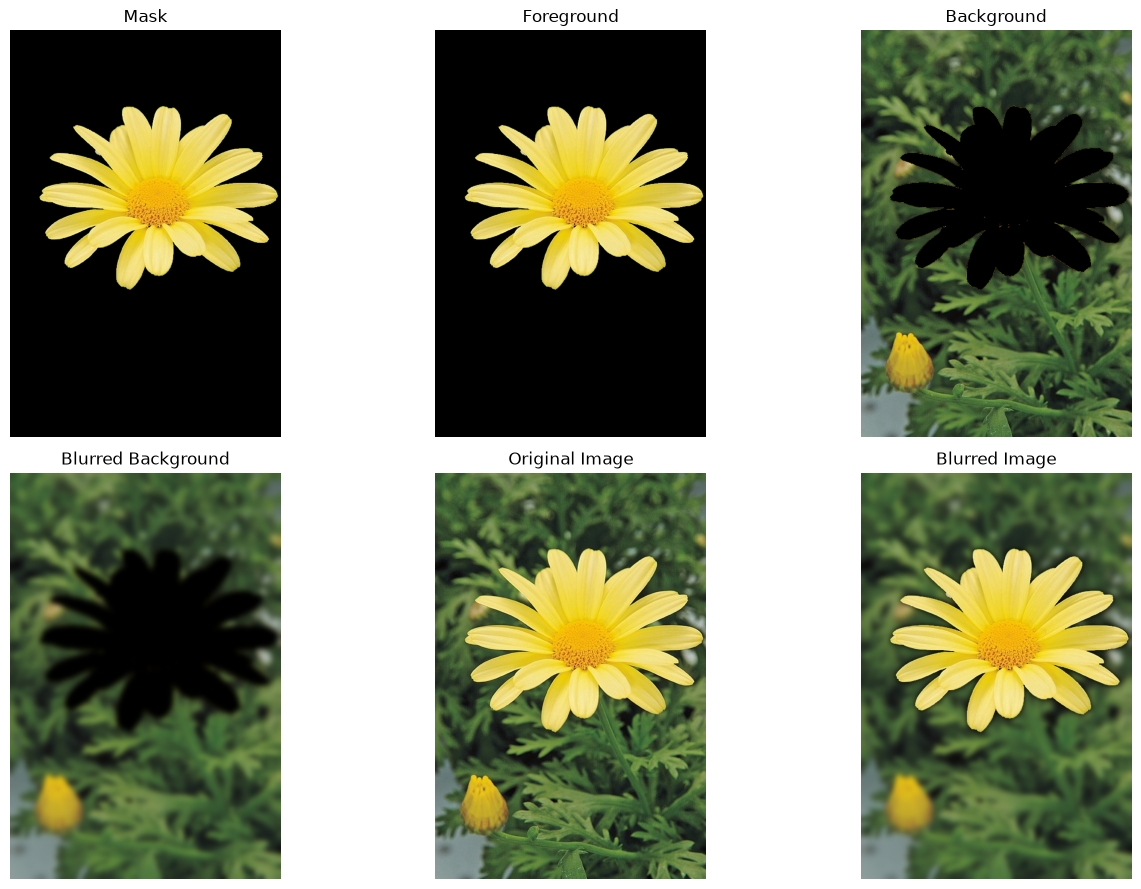

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

axes[0][0].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
axes[0][0].set_title("Mask")
axes[0][0].axis('off')

axes[0][1].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
axes[0][1].set_title("Foreground")
axes[0][1].axis('off')

axes[0][2].imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB))
axes[0][2].set_title("Background")
axes[0][2].axis('off')

axes[1][0].imshow(cv.cvtColor(blurred, cv.COLOR_BGR2RGB))
axes[1][0].set_title("Blurred Background")
axes[1][0].axis('off')

axes[1][1].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
axes[1][1].set_title("Original Image")
axes[1][1].axis('off')

axes[1][2].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
axes[1][2].set_title("Blurred Image")
axes[1][2].axis('off')

plt.tight_layout()
plt.show()

To use grabCut, a rectangle was defined to cover only the yellow flower. Separating the background and foreground using only this rectangular area resulted in the yellow flower as foreground and the rest as the background. (Changing the rectangle will change what features get segmented. For example, if we use the whole image as the rectangle, the foreground will include the flower bud as well).

Then, background was blurred using a Gaussian blur, and merged with the foreground to create the final result.

The background just beyond the edge of the flower can be observed as darker in the new image. This happens because the flower was removed from the background layer, leaving behind a black silhouette. When the Gaussian blur is applied, the background would get averaged with these artificially black pixels as well, creating a darker edge around the boundary of the merge. Blurring the whole image first, and then masking would avoid this mistake.

# Question 10

In [30]:
im = cv.imread("images/q10.jpeg")
d = 9
sigma_r = 75
sigma_s = 75
sigma_gaussian = 75
bilateral = cv.bilateralFilter(im, d, sigma_r, sigma_s)
gaussian = cv.GaussianBlur(im, (9,9), sigma_gaussian)

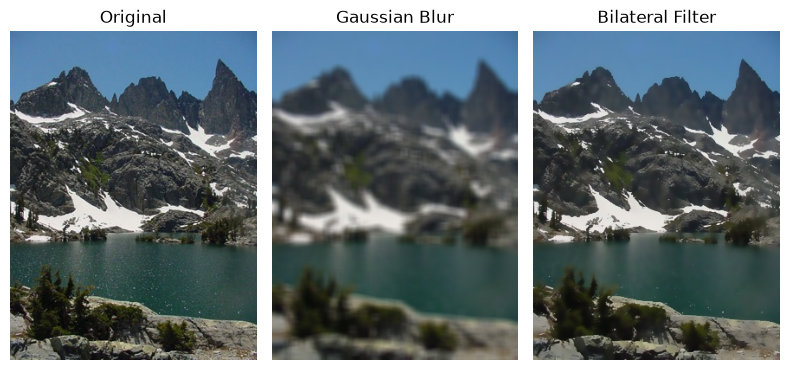

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(8, 4))

axes[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(gaussian, cv.COLOR_BGR2RGB))
axes[1].set_title("Gaussian Blur")
axes[1].axis('off')

axes[2].imshow(cv.cvtColor(bilateral, cv.COLOR_BGR2RGB))
axes[2].set_title("Bilateral Filter")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [32]:
def my_bilateral_filter_color(img, sigma_s, sigma_r, window_size=5):
    img = img.astype(np.float64)
    height, width, channels = img.shape
    output = np.zeros_like(img)
    radius = window_size // 2
    # Pad the images
    padded_img = np.pad(img, ((radius, radius), (radius, radius), (0, 0)), mode='reflect')
    # Spatial kernel is computed once, its value doesn't change across pixels
    spatial_kernel = np.zeros((window_size, window_size))
    for u in range(-radius, radius + 1):
        for v in range(-radius, radius + 1):
            spatial_kernel[u+radius, v+radius] = np.exp(-(u**2 + v**2) / (2 * sigma_s**2))
    for y in range(height):
        for x in range(width):
            center = padded_img[y+radius, x+radius]
            window = padded_img[y:y+window_size, x:x+window_size]
            diff = window - center
            color_dist_sq = np.sum(diff**2, axis=2)
            # Range kernel gives high weight to neighbors with similar colors
            range_kernel = np.exp(-color_dist_sq / (2 * sigma_r**2))
            # Spatial and Range weights are combined.
            combined_weight = spatial_kernel * range_kernel
            weight_sum = np.sum(combined_weight)
            # Apply the same combined weight map to each channel
            for c in range(channels):
                output[y, x, c] = np.sum(combined_weight * window[:, :, c]) / weight_sum

    return np.clip(output, 0, 255).astype(np.uint8)

In [33]:
my_bilateral = my_bilateral_filter_color(im, sigma_s, sigma_r, d)

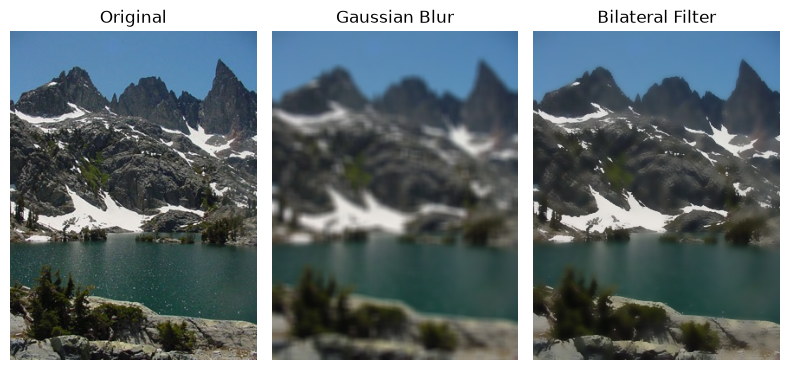

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(8, 4))

axes[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(gaussian, cv.COLOR_BGR2RGB))
axes[1].set_title("Gaussian Blur")
axes[1].axis('off')

axes[2].imshow(cv.cvtColor(my_bilateral, cv.COLOR_BGR2RGB))
axes[2].set_title("Bilateral Filter")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [115]:
print("SSD (mine vs cv.bilateralFilter):", ssd(my_bilateral, bilateral))

SSD (mine vs cv.bilateralFilter): 2.0911542012927056


A Gaussian filter moves a kernel across every pixel in an image, averaging the value of that pixel according to its neighbors. The only relevant factor is the distance between pixels. The result is a uniformly smoothed image. A bilateral filter works differently. The space kernel ($\sigma_s$) behaves similar to the Gaussian kernel, but the color kernel ($\sigma_r$) measures the difference between pixel values as well (It gives higher values to similar colors and lower values to others). Because of this dual approach, edges will be preserved after the blurring.

For this question, $\sigma_s$ and $\sigma_r$ were taken at the value of 75, and $\sigma$ of the Gaussian blur was also comparable to these. The bilateral filter was implemented first through OpenCV's own function, and then a function written from scratch.

The Sum of Squared Differences (SSD) between the results from the actual function and the implemented function was 2.0911542012927056, which is a low enough value to ensure that the results are similar.